2026-05-05 16:18:35,823[INFO] Using GPU: 0
2026-05-05 16:18:35,827[INFO] Use CuPy as backend
2026-05-05 16:18:35,827[INFO] cupy random seed is 2019
2026-05-05 16:18:35,828[INFO] random seed is 1092
2026-05-05 16:18:35,883[INFO] Git Commit Hash: 9e4f5dfa43096053fecf425a65c353443025315a
2026-05-05 16:18:35,885[INFO] use 64 bits


成功加载数据，长度: 6


/curie-home/zengjj/.conda/envs/reno/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1340: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


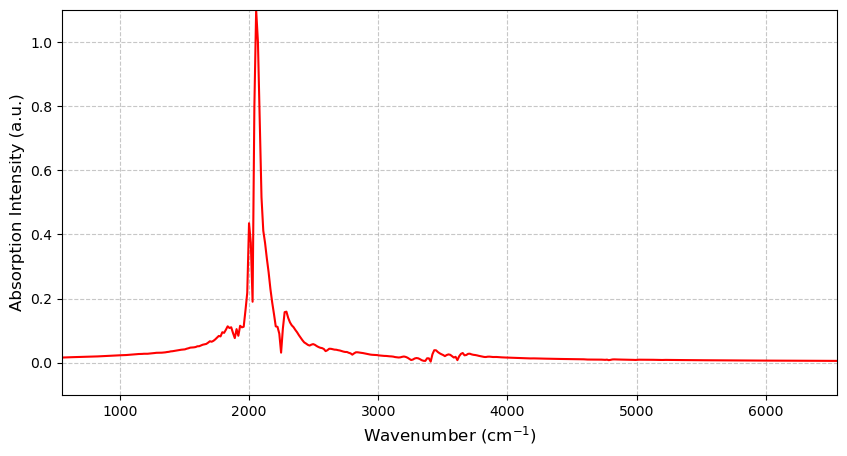

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from renormalizer.utils import constant
# ================= 配置参数 (需与 run_monomer.py 一致) =================
           
# ======================================================================
def autocorr_to_spectrum(path="" ):
    try:
        data = np.load(path)
        print(f"成功加载数据，长度: {len(data)}")
    except:
        print("错误：未找到 autocorr_data.npy 文件！")
        return

    times_au = data["time series"]
    dt_au = times_au[1] - times_au[0]

    autocorr = np.asarray(data["autocorr"])

    # freq: 1/au (Hartree)
    spectrum = np.fft.fft(autocorr)
    freqs_hartree = - np.fft.fftfreq(len(autocorr), d=dt_au) * 2 * np.pi
    
    # Offset (eV)
    freqs_cm = freqs_hartree * constant.au2cm
    
    intensities = np.abs(spectrum)/np.max(spectrum)

    # 数据筛选 (只取正频率附近的结果)
    # 排序以方便画图
    idx = np.argsort(freqs_cm)
    x = freqs_cm[idx]
    y = intensities[idx]

    plt.figure(figsize=(10, 5))

    peak_pos = x[np.argmax(y)]
    plt.xlim(peak_pos - 1500, peak_pos + 4500)
    plt.ylim(-0.1,1.1)
    plt.plot(x, y, color='red', linewidth=1.5)

    plt.xlabel("Wavenumber (cm$^{-1}$)", fontsize=12)
    plt.ylabel("Absorption Intensity (a.u.)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # 保存结果
    # plt.savefig(f"monomer_spectrum.png", dpi=300)
    plt.show()

if __name__ == "__main__":
    autocorr_to_spectrum(path="../multiset/pbi_hexmer_ft_emi_multiset.npz")
    # "../multiset/pbi_dimer.npz"

2026-05-05 21:40:37,679[INFO] Using GPU: 0
2026-05-05 21:40:37,684[INFO] Use CuPy as backend
2026-05-05 21:40:37,685[INFO] cupy random seed is 2019
2026-05-05 21:40:37,685[INFO] random seed is 1092
2026-05-05 21:40:37,741[INFO] Git Commit Hash: 9e4f5dfa43096053fecf425a65c353443025315a
2026-05-05 21:40:37,744[INFO] use 64 bits


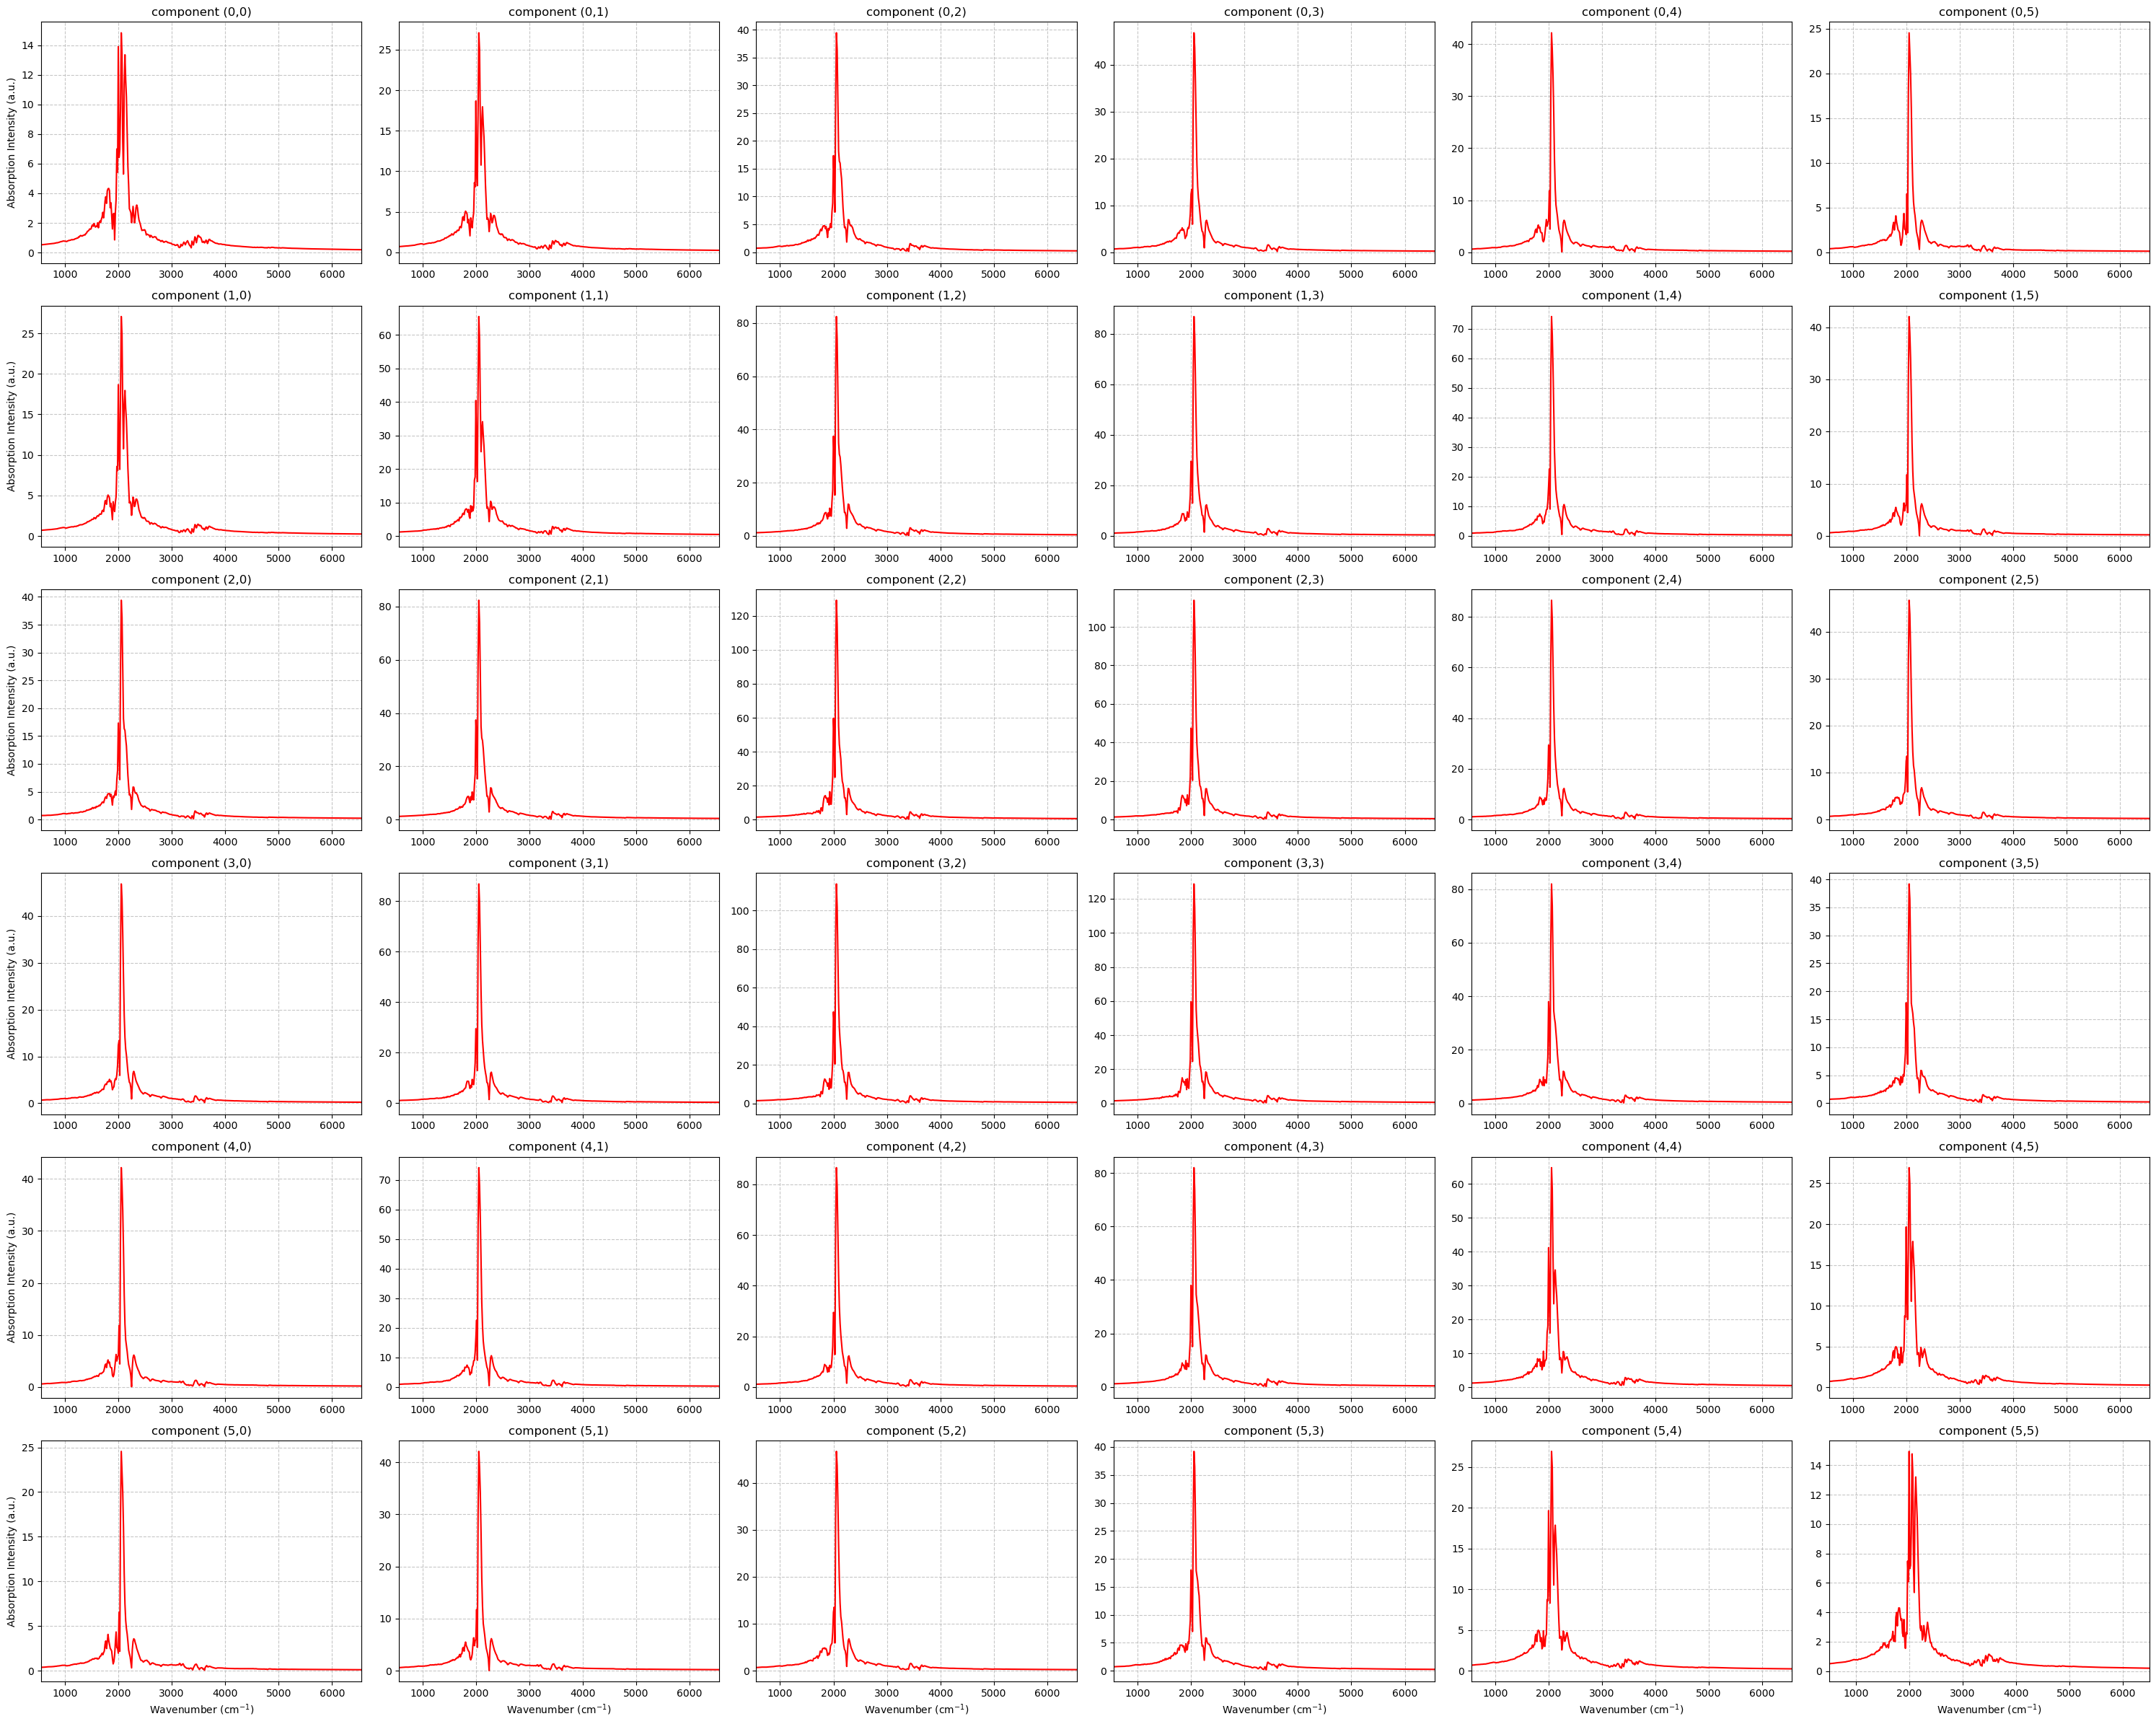

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from renormalizer.utils import constant

path = "../multiset/pbi_hexmer_ft_emi_multiset.npz"
data = np.load(path)
times_au = data["time series"]
dt_au = times_au[1] - times_au[0]

autocorr_components = np.asarray(data["autocorr_components"])

def autocorr_to_spectrum_no_broadening(autocorr):
    spectrum = np.fft.fft(autocorr)
    freqs_hartree = -np.fft.fftfreq(len(autocorr), d=dt_au) * 2 * np.pi
    freqs_cm = freqs_hartree * constant.au2cm
    intensities = np.abs(spectrum) # np.abs(spectrum) / np.max(np.abs(spectrum))
    idx = np.argsort(freqs_cm)
    return freqs_cm[idx], intensities[idx]

def plot_component(ax, x, y, title):
    peak_pos = x[np.argmax(y)]
    ax.plot(x, y, color='red', linewidth=1.5)
    ax.set_xlim(peak_pos - 1500, peak_pos + 4500)
    ax.set_title(title, fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.7)

n_bra, n_ket = autocorr_components.shape[1], autocorr_components.shape[2]
fig, axes = plt.subplots(n_bra, n_ket, figsize=(5 * n_ket, 4 * n_bra), squeeze=False)

for i in range(n_bra):
    for j in range(n_ket):
        x_c, y_c = autocorr_to_spectrum_no_broadening(autocorr_components[:, i, j])
        ax = axes[i, j]
        plot_component(ax, x_c, y_c, f"component ({i},{j})")
        if i == n_bra - 1:
            ax.set_xlabel("Wavenumber (cm$^{-1}$)", fontsize=10)
        if j == 0:
            ax.set_ylabel("Absorption Intensity (a.u.)", fontsize=10)

plt.tight_layout()
plt.show()

## ABS

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from renormalizer.utils import constant

path = "../multiset/pbi_hexmer_ft_abs_multiset.npz"
data = np.load(path)
times_au = data["time series"]
dt_au = times_au[1] - times_au[0]

autocorr_components = np.asarray(data["autocorr_components"])

def autocorr_to_spectrum_no_broadening(autocorr):
    spectrum = np.fft.fft(autocorr)
    freqs_hartree = -np.fft.fftfreq(len(autocorr), d=dt_au) * 2 * np.pi
    freqs_cm = freqs_hartree * constant.au2cm
    intensities = np.abs(spectrum) # np.abs(spectrum) / np.max(np.abs(spectrum))
    idx = np.argsort(freqs_cm)
    return freqs_cm[idx], intensities[idx]

def plot_component(ax, x, y, title):
    peak_pos = x[np.argmax(y)]
    ax.plot(x, y, color='red', linewidth=1.5)
    ax.set_xlim(peak_pos - 1500, peak_pos + 4500)
    ax.set_title(title, fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.7)

n_bra, n_ket = autocorr_components.shape[1], autocorr_components.shape[2]
fig, axes = plt.subplots(n_bra, n_ket, figsize=(5 * n_ket, 4 * n_bra), squeeze=False)

for i in range(n_bra):
    for j in range(n_ket):
        x_c, y_c = autocorr_to_spectrum_no_broadening(autocorr_components[:, i, j])
        ax = axes[i, j]
        plot_component(ax, x_c, y_c, f"component ({i},{j})")
        if i == n_bra - 1:
            ax.set_xlabel("Wavenumber (cm$^{-1}$)", fontsize=10)
        if j == 0:
            ax.set_ylabel("Absorption Intensity (a.u.)", fontsize=10)

plt.tight_layout()
plt.show()